In [1]:
from cytograph import Algorithm, creates, requires, div0
from cytograph.visualization.scatter import scatterc, scattern
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from typing import List
import shoji
import cytograph as cg
import cytograph.visualization as cgplot
import collections
from typing import List, Optional
import matplotlib.patheffects as PathEffects
import fastcluster
import igraph
import leidenalg as la
import scipy.cluster.hierarchy as hc
from hmmlearn import hmm
from openTSNE import TSNE
from pynndescent import NNDescent
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from tqdm import trange
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from cytograph.visualization import Colorizer
from matplotlib.lines import Line2D
import scipy as sci
import loompy
import scanpy as sc
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

In [76]:
# Load the sample data into your local Shoji database
GBO = sc.read_h5ad('/proj/cytograph/jesper/GBM_revision/h5ad/bulk_samples_GBO_treated.h5ad')

In [77]:
GBO.obs

,>=Q30,Condition,Mreads,Sample,Sample_Condition,Sample_Time_Condition,Time,Time_Condition,Time_Sample
CellID,,,,,,,,,
P30308_101,88.85,-P-H,21.35,SL007,SL007 _-P-H,SL007 0h,0h,0h,0h_SL007
P30308_102,89.27,-P-H,22.31,SL013,SL013 _-P-H,SL013 0h,0h,0h,0h_SL013
P30308_103,89.24,-P-H,23.64,SL014,SL014 _-P-H,SL014 0h,0h,0h,0h_SL014
P30308_104,89.15,-P-H,26.13,SL027A,SL027A_-P-H,SL027A 0h,0h,0h,0h_SL027A
P30308_106,89.11,-P+H,23.06,SL013,SL013 _-P+H,SL013 H24h,24h,H24h,24h_SL013
P30308_107,89.10,-P+H,20.10,SL014,SL014 _-P+H,SL014 H24h,24h,H24h,24h_SL014
P30308_108,89.48,-P+H,25.10,SL027A,SL027A_-P+H,SL027A H24h,24h,H24h,24h_SL027A
P30308_109,89.07,+P+H,26.24,SL007,SL007 _+P+H,SL007 HP24h,24h,HP24h,24h_SL007
P30308_110,89.21,+P+H,25.95,SL013,SL013 _+P+H,SL013 HP24h,24h,HP24h,24h_SL013


In [78]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

In [79]:
gene_list

array(['CHI3L1', 'ANXA2', 'ANXA1', 'CD44', 'VIM', 'MT2A', 'C1S', 'NAMPT',
       'EFEMP1', 'C1R', 'SOD2', 'IFITM3', 'TIMP1', 'SPP1', 'A2M',
       'S100A11', 'MT1X', 'S100A10', 'FN1', 'LGALS1', 'S100A16', 'CLIC1',
       'MGST1', 'RCAN1', 'TAGLN2', 'NPC2', 'SERPING1', 'TCIM', 'EMP1',
       'APOE', 'CTSB', 'C3', 'LGALS3', 'MT1E', 'EMP3', 'SERPINA3',
       'ACTN1', 'PRDX6', 'IGFBP7', 'SERPINE1', 'PLP2', 'MGP', 'CLIC4',
       'GFPT2', 'GSN', 'NNMT', 'TUBA1C', 'GJA1', 'TNFRSF1A', 'WWTR1',
       'HILPDA', 'ADM', 'DDIT3', 'NDRG1', 'HERPUD1', 'DNAJB9', 'TRIB3',
       'ENO2', 'AKAP12', 'SQSTM1', 'ATF3', 'NRN1', 'SLC2A1', 'BNIP3',
       'INSIG2', 'IGFBP3', 'PPP1R15A', 'PLOD2', 'GBE1', 'SLC2A3', 'FTL',
       'WARS1', 'ERO1A', 'XPOT', 'HSPA5', 'GDF15', 'EPAS1', 'LDHA',
       'P4HA1', 'SERTAD1', 'PFKP', 'PGK1', 'EGLN3', 'SLC6A6', 'CA9',
       'BNIP3L', 'RPL21', 'TRAM1', 'UFM1', 'ASNS', 'GOLT1B', 'ANGPTL4',
       'SLC39A14', 'CDKN1A', 'HSPA9'], dtype='<U8')

In [118]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[gene_list]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0))))
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H'])

In [119]:
merg

,0,24,72,144
CellID,,,,
+P-H,2.270127,2.849855,2.790936,2.636011
-P+H,2.270127,3.505811,4.228139,2.149148
+P+H,2.270127,3.515676,5.070199,2.677313


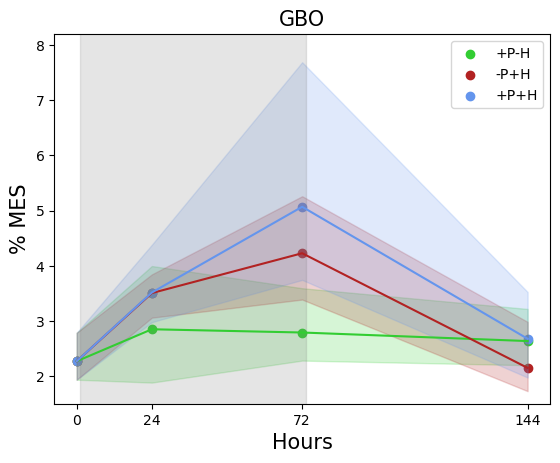

In [83]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [116]:
# Load the sample data into your local Shoji database
GBO_c = sc.read_h5ad('/proj/cytograph/jesper/GBM_revision/h5ad/bulk_samples_GBO_control_smartseq_2025.h5ad')

In [117]:
df = GBO_c.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[gene_list]
df_mes = MES_df.sum(axis=1)
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename)
merged1_c = merged1_c.multiply(100)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0)
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0)
merg_c

,0,24,72,144
SL007,2.822486,2.513223,1.856766,2.637098
SL013,3.559915,1.966555,1.662709,1.683068
SL014,8.099460,4.573310,4.142731,3.600167
SL027A,4.266886,2.664684,3.198863,3.068915


In [121]:
merg.loc['-P-H'] = merg1_c
Max = np.max(merg_c)
Min = np.min(merg_c)

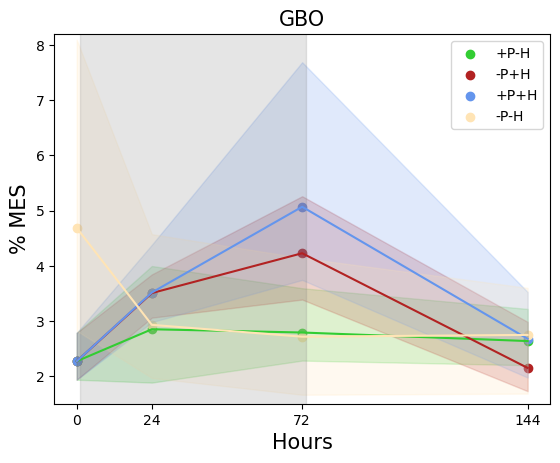

In [122]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.2)
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [88]:
#+p-h all timepoints vs start
x, p1 = mannwhitneyu(merged1[0:4]['0'], merged1[0:4]['24'], alternative='less')
x, p2 = mannwhitneyu(merged1[0:4]['0'], merged1[0:4]['72'], alternative='less')
x, p3 = mannwhitneyu(merged1[0:4]['0'], merged1[0:4]['144'], alternative='less') 
#-p+h all timepoints vs start
x, p4 = mannwhitneyu(merged1[4:8]['0'], merged1[5:8]['24'], alternative='less')
x, p5 = mannwhitneyu(merged1[4:8]['0'], merged1[4:8]['72'], alternative='less')
x, p6 = mannwhitneyu(merged1[4:8]['0'], merged1[4:8]['144'], alternative='less') 
#+p+h all timepoints vs start
x, p7 = mannwhitneyu(merged1[8:12]['0'], merged1[8:12]['24'], alternative='less')
x, p8 = mannwhitneyu(merged1[8:12]['0'], merged1[8:12]['72'], alternative='less')
x, p9 = mannwhitneyu(merged1[8:12]['0'], merged1[8:12]['144'], alternative='less') 

In [89]:
comp = ['+p-H_24vs0h','+p-H_72vs0h','+p-H_144vs0h','-p+H_24vs0h','-p+H_72vs0h','-p+H_144vs0h','+p+H_24vs0h','+p+H_72vs0h','+p+H_144vs0h']

In [90]:
x = pd.Series([p1,p2,p3,p4,p5,p6,p7,p8,p9], index =comp)
x

+p-H_24vs0h     0.342857
+p-H_72vs0h     0.171429
+p-H_144vs0h    0.171429
-p+H_24vs0h     0.028571
-p+H_72vs0h     0.014286
-p+H_144vs0h    0.757143
+p+H_24vs0h     0.014286
+p+H_72vs0h     0.014286
+p+H_144vs0h    0.171429
dtype: float64

In [91]:
x, p1 =  mannwhitneyu(merged1[0:4]['72'], merged1[0:4]['144'], alternative='greater')
x, p2 =  mannwhitneyu(merged1[4:8]['72'], merged1[4:8]['144'], alternative='greater')
x, p3 = mannwhitneyu(merged1[8:12]['72'], merged1[8:12]['144'], alternative='greater')

In [92]:
p1, p2, p3

(0.24285714285714285, 0.014285714285714285, 0.014285714285714285)

In [93]:
comp = ['+p-H_72vs144h','-p+H_72vs144h','+p+H_72vs144h']
x = pd.Series([p1,p2,p3], index =comp)
x

+p-H_72vs144h    0.242857
-p+H_72vs144h    0.014286
+p+H_72vs144h    0.014286
dtype: float64

In [94]:
merged1.loc['SL007_-P-H'] = merg_c.loc['SL007']
merged1.loc['SL013_-P-H'] = merg_c.loc['SL013']
merged1.loc['SL014_-P-H'] = merg_c.loc['SL014']
merged1.loc['SL027A_-P-H'] = merg_c.loc['SL027A']


In [98]:
#Save other gene modules from Neftel
AC = np.array(["CST3","S100B","SLC1A3","HEPN1","HOPX","MT3","SPARCL1","MLC1","GFAP","FABP7","BCAN","PON2","METTL7B","SPARC","GATM","RAMP1","PMP2","AQP4","DBI","EDNRB","PTPRZ1","CLU","PMP22","ATP1A2","S100A16","HEY1","PCDHGC3","TTYH1","NDRG2","PRCP","ATP1B2","AGT","PLTP","GPM6B","F3","RAB31","PLPP3","ANXA5","TSPAN7"])
OPC = np.array(["BCAN","PLP1","GPR17","FIBIN","LHFPL3","OLIG1","PSAT1","SCRG1","OMG","APOD","SIRT2","TNR","THY1","PHYHIPL","SOX2-OT","NKAIN4","PLPPR1","PTPRZ1","VCAN","DBI","PMP2","CNP","TNS3","LIMA1","CA10","PCDHGC3","CNTN1","SCD5","P2RX7","CADM2","TTYH1","FGF12","PACC1","NEU4","FXYD6","RNF13","RTKN","GPM6B","LMF1","ALCAM","PGRMC1","PLAAT1","BCAS1","RAB31","PLLP","FABP5","NLGN3","SERINC5","EPB41L2","GPR37L1"])
NPC1 = np.array(["DLL3","DLL1","SOX4","TUBB3","HES6","TAGLN3","NEU4","MARCKSL1","CD24","STMN1","TCF12","BEX1","OLIG1","MAP2","FXYD6","PTPRS","MLLT11","NPPA","BCAN","MEST","ASCL1","BTG2","DCX","NXPH1","JPT1","PFN2","SCG3","MYT1","CHD7","ADGRG1","TUBA1A","PCBP4","ETV1","SHD","TNR","AMOTL2","DBN1","HIP1","ABAT","ELAVL4","LMF1","GRIK2","SERINC5","TSPAN13","ELMO1","GLCCI1","SEZ6L","LRRN1","SEZ6","SOX11"])
NPC2 = np.array(["STMN2","CD24","RND3","NSG2","TUBB3","MIAT","DCX","NSG1","ELAVL4","MLLT11","DLX6-AS1","SOX11","NREP","FNBP1L","TAGLN3","STMN4","DLX5","SOX4","MAP1B","RBFOX2","IGFBPL1","STMN1","JPT1","DPYSL3","SEPTIN3","PKIA","ATP1B1","DYNC1I1","CD200","SNAP25","PAK3","NDRG4","KIF5A","UCHL1","ENO2","KIF5C","DDAH2","TUBB2A","LBH","LINC01102","TCF4","GNG3","NFIB","DPYSL5","CRABP1","DBN1","NFIX","CEP170","BLCAP"])
NPC = np.concatenate((NPC1, NPC2))

In [103]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[OPC]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0))))
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H'])

In [104]:
df = GBO_c.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[OPC]
df_mes = MES_df.sum(axis=1)
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename)
merged1_c = merged1_c.multiply(100)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0)
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0)
merg.loc['-P-H'] = merg1_c
Max = np.max(merg_c)
Min = np.min(merg_c)

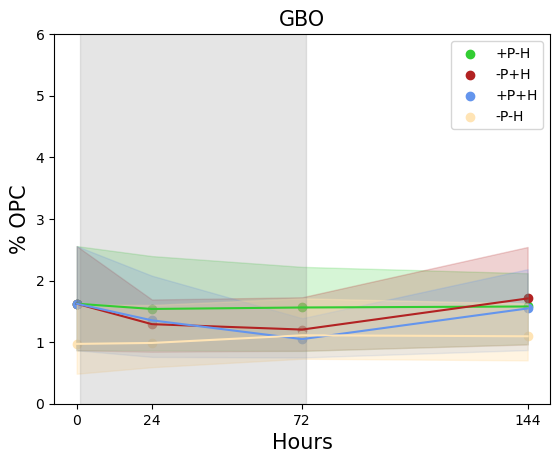

In [105]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

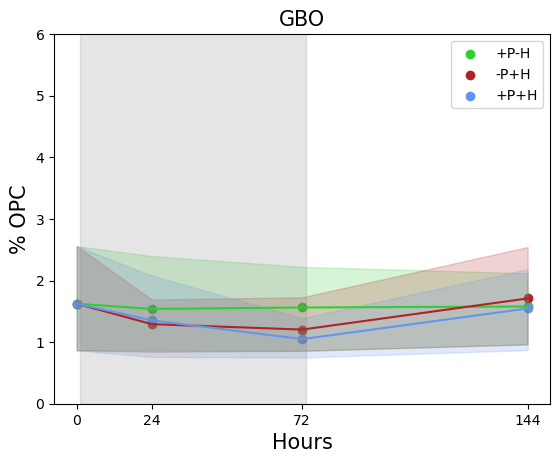

In [106]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [107]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[AC]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0))))
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H'])

In [108]:
df = GBO_c.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[AC]
df_mes = MES_df.sum(axis=1)
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename)
merged1_c = merged1_c.multiply(100)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0)
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0)
merg.loc['-P-H'] = merg1_c
Max = np.max(merg_c)
Min = np.min(merg_c)

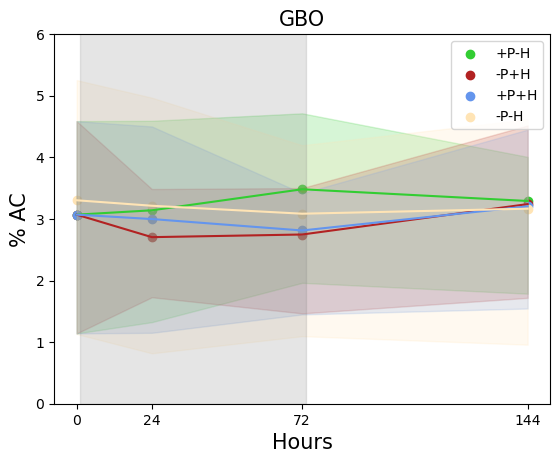

In [109]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.2)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

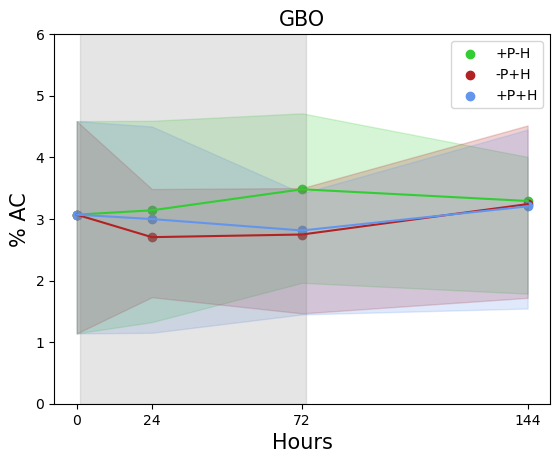

In [110]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [111]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[NPC]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0))))
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H'])

In [112]:
df = GBO_c.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[NPC]
df_mes = MES_df.sum(axis=1)
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename)
merged1_c = merged1_c.multiply(100)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0)
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0)
merg.loc['-P-H'] = merg1_c
Max = np.max(merg_c)
Min = np.min(merg_c)

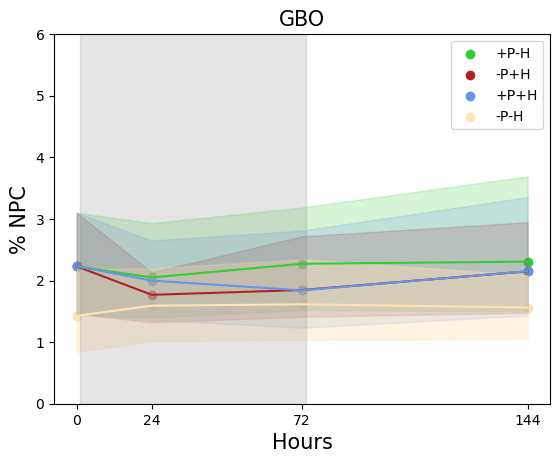

In [113]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

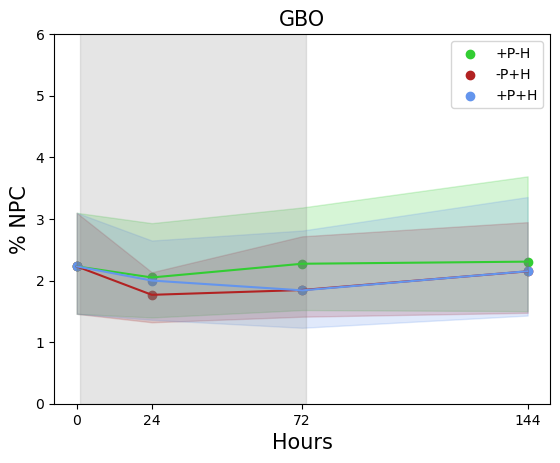

In [115]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)